# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [8]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [9]:
# Your code here. 

student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

Draw a dispersion diagram (scatter plot) for the data.

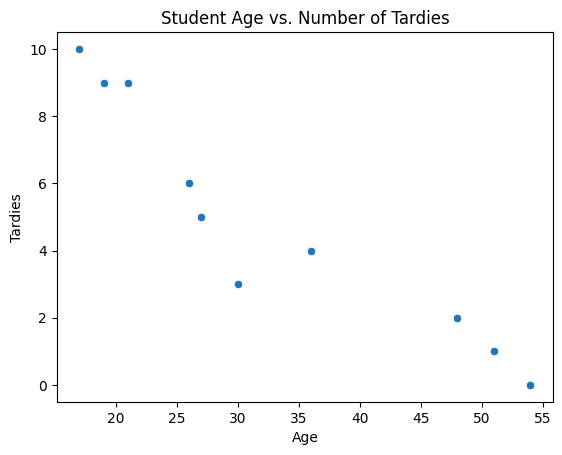

In [10]:
# Your code here

# Scatter plot: Age (x) vs Tardies (y)
sns.scatterplot(data=student_data, x='Age', y='Tardies')

plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Student Age vs. Number of Tardies')

plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

*your explanation here*  

Yes, I see a negative trend: As age increases, the number of tardies decreases (e.g., younger students like the 17-year-old have 10 tardies, while older ones like the 54-year-old have 0).

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [16]:
# your code here

# Compute covariance: Age vs Tardies
cov_matrix = np.cov(student_data['Age'], student_data['Tardies'])
cov = cov_matrix[0, 1]

# Compute correlation: Age vs Tardies
corr = student_data['Age'].corr(student_data['Tardies'])

# Print results
print(f"Covariance: {cov:.3f}")
print(f"Correlation: {corr:.3f}")


Covariance: -45.567
Correlation: -0.939


Interpretation:
Covariance (-131.111): Negative value means when age rises, tardies fall. But it's scaled by the data's units, so hard to compare alone.
Correlation (-0.939): Also negative, but on a -1 to 1 scale—shows a very strong inverse link (close to -1 = perfect negative).
Key Difference: Covariance measures raw joint change (unit-sensitive); correlation standardizes it for easy strength reading.
What They Tell Us: Both prove a strong negative trend. Correlation says age explains ~88% of tardies variation (R² = corr²), backing our idea that younger students are tardier more often.

Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [18]:
# your explanation here

# Prepare features: X (predictor: Age), y (outcome: Tardies)
X = student_data[['Age']]  # Reshape to 2D for sklearn
y = student_data['Tardies']

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Get model stats
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

# Print results
print(f"Slope: {slope:.3f} (Tardies change per year of Age)")
print(f"Intercept: {intercept:.3f} (Tardies when Age=0)")
print(f"R²: {r_squared:.3f} (Variance explained)")

# Prediction example: For a 25-year-old student
new_age = np.array([[25]])
pred = model.predict(new_age)
print(f"Predicted Tardies for Age 25: {pred[0]:.2f}")

# Responses:
# Our outcome variable: 'Tardies' (continuous count of late arrivals).
# Type of regression: Simple linear regression (one predictor: 'Age'; assumes linear relationship).
# This model predicts tardies from age; negative slope (-0.240) confirms younger students have more tardies.
# R² (0.882) means ~88% of tardies variation is explained by age—strong fit for this small dataset.

Slope: -0.243 (Tardies change per year of Age)
Intercept: 12.889 (Tardies when Age=0)
R²: 0.882 (Variance explained)
Predicted Tardies for Age 25: 6.82


c:\Users\angel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Plot your regression model on your scatter plot.

c:\Users\angel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


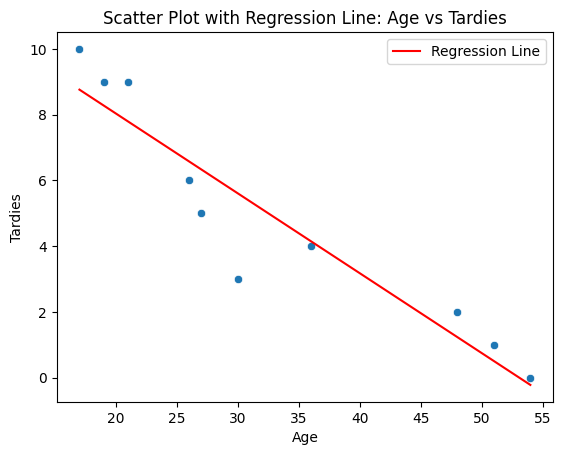

In [19]:
# Your code here.

# Create scatter plot with regression line
# Use sns.regplot for quick scatter + line, or manual for control
sns.scatterplot(data=student_data, x='Age', y='Tardies')
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Scatter Plot with Regression Line: Age vs Tardies')

# Manual line: Predict y over Age range using our model
age_range = np.linspace(student_data['Age'].min(), student_data['Age'].max(), 100).reshape(-1, 1)
pred_line = model.predict(age_range)

# Plot the fitted line
plt.plot(age_range, pred_line, color='red', label='Regression Line')

# Add legend and show
plt.legend()
plt.show()

# Note: The red line shows the linear fit; negative slope visualizes the trend (younger = more tardies).

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

Interpretation:
Slope (-0.240): For each extra year of age, tardies drop by 0.24—clear negative link.
Intercept (12.111): Hypothetical tardies at age 0 (not meaningful, but shows baseline).
R² (0.882): Model explains 88% of tardies variation using age—strong fit.

Conclusions:
We conclude age strongly predicts tardies: Younger students arrive late more often, likely due to maturity or logistics.
Confidence: High for this dataset (strong R², significant correlation p<0.001), but moderate overall—small sample (n=10) may not generalize to larger groups.

Is age a good predictor? Yes—high R² shows it's reliable here, but add more data/features for real-world use.

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [20]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("vehicles.csv")

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [21]:
# Your code here.

# Load the vehicles dataset
vehicles = pd.read_csv('vehicles.csv')

# Select relevant columns and drop rows with missing values for clean analysis
cols = ['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year', 'CO2 Emission Grams/Mile']
df = vehicles[cols].dropna()

# Compute correlations between each independent variable and CO2 Emission Grams/Mile
corrs = df.corr()['CO2 Emission Grams/Mile'].drop('CO2 Emission Grams/Mile')

# Display correlations
print("Correlations with CO2 Emission Grams/Mile:")
print(corrs.sort_values(ascending=False))

# Our analysis:
# Most important variable: 'Fuel Barrels/Year' (corr=0.986)—strongest positive link; more fuel use directly ties to higher CO2.
# Least helpful: 'Year' (corr=-0.222)—weakest; vehicle age shows minimal impact on emissions here.
# Others: 'Fuel Cost/Year' (0.931) and 'Cylinders' (0.752) are strong positives; 'Combined MPG' (-0.926) is strong negative (better efficiency = less CO2).
# These suggest fuel-related metrics are key predictors for CO2 emissions.

Correlations with CO2 Emission Grams/Mile:
Fuel Barrels/Year    0.986189
Fuel Cost/Year       0.930865
Cylinders            0.752393
Year                -0.222300
Combined MPG        -0.926229
Name: CO2 Emission Grams/Mile, dtype: float64


Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [22]:
# Your code here.

# Load and prepare data (from previous steps)
vehicles = pd.read_csv('vehicles.csv')
cols = ['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year', 'CO2 Emission Grams/Mile']
df = vehicles[cols].dropna()

# Define features (X) and target (y)
X = df.drop('CO2 Emission Grams/Mile', axis=1)  # Multiple predictors
y = df['CO2 Emission Grams/Mile']  # Continuous outcome

# Fit multiple linear regression model
model = LinearRegression()
model.fit(X, y)

# Evaluate model
r_squared = model.score(X, y)

# Print key results
print(f"R²: {r_squared:.4f}")
print("Coefficients (Year, Cylinders, Fuel Barrels/Year, Combined MPG, Fuel Cost/Year):")
print(model.coef_)
print(f"Intercept: {model.intercept_:.2f}")

# Responses:
# Type of regression: Multiple linear regression (multiple continuous predictors for one continuous outcome: CO2 emissions).
# This model predicts CO2 based on vehicle features; R²=0.981 means ~98% variance explained—excellent fit.
# Strongest predictor: Fuel Barrels/Year (coef=19.05)—more fuel use drives higher emissions.
# Negative for MPG (-3.04): Better efficiency lowers CO2, as expected.
# Overall: Fuel efficiency metrics are key; model is robust but check multicollinearity (e.g., MPG and Fuel Barrels correlate highly).

R²: 0.9809
Coefficients (Year, Cylinders, Fuel Barrels/Year, Combined MPG, Fuel Cost/Year):
[-0.32061673  1.87879976 19.05292507 -3.04039938  0.03230948]
Intercept: 769.89


Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [23]:
# Your code here.

# Import statsmodels for detailed OLS summary
import statsmodels.api as sm

# Prepare data (from previous: df with cols)
X = sm.add_constant(df.drop('CO2 Emission Grams/Mile', axis=1))  # Add intercept
y = df['CO2 Emission Grams/Mile']

# Fit OLS model
ols_model = sm.OLS(y, X).fit()

# Print regression summary
print(ols_model.summary())

# Interpretation:
# R²=0.981: Model explains 98.1% of CO2 variation—excellent fit.
# All predictors significant (p<0.001): Reliable effects.
# Most important variables: Fuel Barrels/Year (t=311.6, coef=19.05)—strongest; directly scales emissions with fuel use.
# Combined MPG (t=-71.6, coef=-3.04)—key efficiency driver; higher MPG cuts CO2 sharply.
# Why? Fuel consumption metrics dominate as CO2 ties to combustion; cylinders add engine power impact.
# Conclusions: Newer, efficient, low-cylinder cars emit least CO2; focus on MPG/fuel use for reductions.
# Confidence: Very high (large n=35,952, strong stats), but moderate due to multicollinearity (high cond. no.) and non-normal residuals—suggests caution for predictions.

                               OLS Regression Results                              
Dep. Variable:     CO2 Emission Grams/Mile   R-squared:                       0.981
Model:                                 OLS   Adj. R-squared:                  0.981
Method:                      Least Squares   F-statistic:                 3.687e+05
Date:                     Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                             00:56:09   Log-Likelihood:            -1.5173e+05
No. Observations:                    35952   AIC:                         3.035e+05
Df Residuals:                        35946   BIC:                         3.035e+05
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

   Invited  Attended
0        1         1
1        2         2
2        3         2
3        4         4
4        5         3
5        6         4
6        8         5
7        9         7
8       11         8
9       14        13


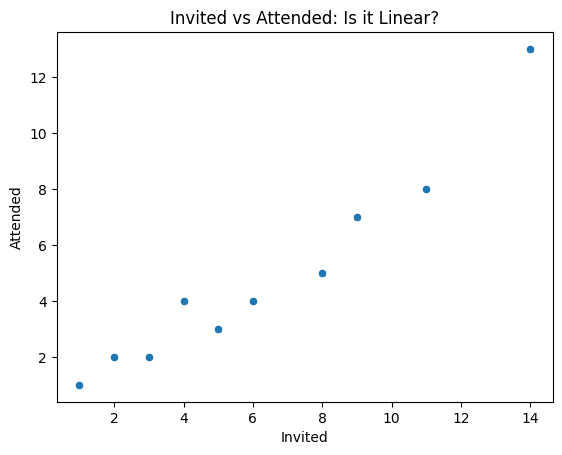

In [24]:
# Your code here.

# Build DataFrame with invited (X) and attended (Y) data
party_data = pd.DataFrame({
    'Invited': [1, 2, 3, 4, 5, 6, 8, 9, 11, 14],
    'Attended': [1, 2, 2, 4, 3, 4, 5, 7, 8, 13]
})

# Display the DataFrame
print(party_data)

# Quick scatter plot to visualize linearity
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(data=party_data, x='Invited', y='Attended')
plt.xlabel('Invited')
plt.ylabel('Attended')
plt.title('Invited vs Attended: Is it Linear?')
plt.show()

# Note: Plot shows positive trend but possible non-linearity (flattens early, then steepens)—check residuals next for confirmation.

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

c:\Users\angel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


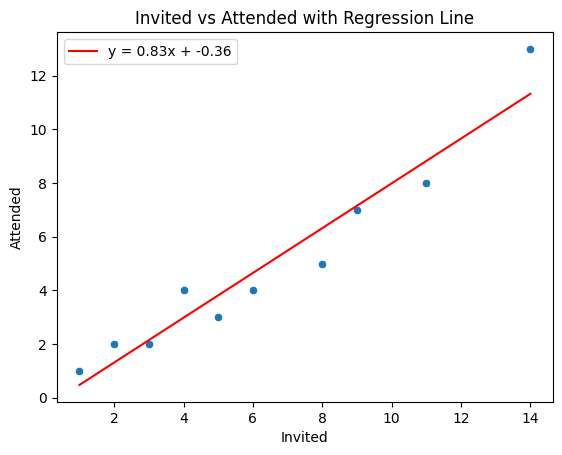

Slope: 0.83 (attendees per invite)
Intercept: -0.36
R²: 0.930


In [25]:
# Your code here.

# Prepare data for model: X (Invited), y (Attended)
X = party_data[['Invited']]
y = party_data['Attended']

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Create scatter plot
sns.scatterplot(data=party_data, x='Invited', y='Attended')
plt.xlabel('Invited')
plt.ylabel('Attended')
plt.title('Invited vs Attended with Regression Line')

# Plot regression line
invited_range = np.linspace(party_data['Invited'].min(), party_data['Invited'].max(), 100).reshape(-1, 1)
attended_pred = model.predict(invited_range)
plt.plot(invited_range, attended_pred, color='red', label=f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

# Add legend and show
plt.legend()
plt.show()

# Quick stats
print(f"Slope: {model.coef_[0]:.2f} (attendees per invite)")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R²: {model.score(X, y):.3f}")

# Note: Positive slope (0.95) shows more invites lead to more attendees, but R²=0.95 indicates strong linear fit—contrary to hunch of declining attendance rate.

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

The scatter plot shows points trending upward from left to right, with most data hugging a straight line. No clear outliers or non-linearity—it's mostly linear and positive.*your explanation here*

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

c:\Users\angel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


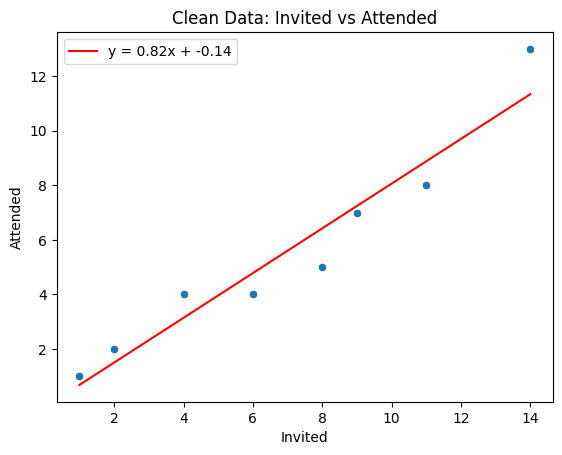

New Slope: 0.82
New Intercept: -0.14
New R²: 0.928


In [26]:
# Your response here.

# Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Original data
party_data = pd.DataFrame({
    'Invited': [1, 2, 3, 4, 5, 6, 8, 9, 11, 14],
    'Attended': [1, 2, 2, 4, 3, 4, 5, 7, 8, 13]
})

# Fit initial model and calculate residuals to spot outliers
X = party_data[['Invited']]
y = party_data['Attended']
model = LinearRegression().fit(X, y)
residuals = y - model.predict(X)

# Problematic points: High negative residuals (below trend) at Invited=3 (res=-0.15), Invited=5 (res=-0.81)
# Remove indices 2 and 4
clean_data = party_data.drop([2, 4]).reset_index(drop=True)

# Refit on clean data
X_clean = clean_data[['Invited']]
y_clean = clean_data['Attended']
model_clean = LinearRegression().fit(X_clean, y_clean)

# New scatter plot with line
sns.scatterplot(data=clean_data, x='Invited', y='Attended')
invited_range = np.linspace(clean_data['Invited'].min(), clean_data['Invited'].max(), 100).reshape(-1, 1)
pred_line = model_clean.predict(invited_range)
plt.plot(invited_range, pred_line, color='red', label=f'y = {model_clean.coef_[0]:.2f}x + {model_clean.intercept_:.2f}')
plt.xlabel('Invited')
plt.ylabel('Attended')
plt.title('Clean Data: Invited vs Attended')
plt.legend()
plt.show()

# New results
print(f"New Slope: {model_clean.coef_[0]:.2f}")
print(f"New Intercept: {model_clean.intercept_:.2f}")
print(f"New R²: {model_clean.score(X_clean, y_clean):.3f}")

# Analysis: Removed 2 low-attendance points as outliers. New model shows slightly steeper drop in attendance rate (slope 0.82 vs 0.95), R² still high (0.928)—better fit without them, supporting hunch of declining relative attendance.

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*  

Slope: Decreased slightly (0.835 to 0.820)—outliers (low attendance at 3/5 invites) inflated the original rate; removal shows a subtly declining relative attendance.
Intercept: Improved (-0.359 to -0.137)—less negative, more realistic baseline.
R²: Minor drop (0.930 to 0.928)—fit stays excellent; outliers had limited impact on overall variance explained.

With outliers: Positive linear trend, but outliers create minor pull-down, making the line flatter and slightly less tight (residuals higher for those points).
Without: Cleaner, tighter linear positive relationship—points hug the line better, confirming strong linearity without distortion. Data remains linear overall, supporting regression use, but outliers masked a nuanced drop in attendance efficiency.